# Project 4 Workbook: Responsible AI Fairness Monitoring in Production

You are the external responsible-AI and model-risk audit team for a mortgage decision-support system.

Your goal is not only to train a model. Your goal is to decide whether the system should be deployed as-is, deployed with controls, returned for remediation, or rejected.

Primary dataset: prepared HMDA project slice in `data/hmda_project4_slice.csv.gz`.


## Submission Rules (Read First)

This workbook is graded for responsible-AI reasoning, not for maximizing one model metric.

Required outputs:
1. M0 data and model-risk assessment.
2. M1 baseline models, validation discipline, calibration, and threshold policy.
3. M2 fairness audit across multiple definitions.
4. M3 at least two mitigation approaches from different categories.
5. M4 production monitoring simulation with at least one fairness incident investigation.
6. M5 final deployment recommendation and model card.

Coding expectation:
- Cells marked `TODO REQUIRED` must be implemented by students.
- You may reuse ideas from the tutorial, but you must write your own HMDA-specific implementation.
- Do not leave placeholder text in required reflection sections.

Not allowed:
- Treating historical HMDA labels as neutral ground truth.
- Claiming fairness from one metric only.
- Dropping protected attributes and declaring the model fair.
- Tuning thresholds or mitigation choices on the test set.
- Reporting fairness metrics without sample sizes.


## Milestone Map

- M0: Data and Model Risk Assessment
- M1: Baseline Models and Threshold Policy
- M2: Fairness Audit Across Definitions
- M3: Mitigation and Trade-Off Analysis
- M4: Production Monitoring and Incident Response
- M5: Deployment Recommendation and Model Card


## Anti-Shortcut Protocol (Mandatory)

Your reasoning must be auditable.

Required controls:
1. Evidence trace tags for every major claim.
2. A fairness-definition decision log.
3. A mitigation trade-off log.
4. An incident investigation worksheet.
5. A final evidence map.
6. Oral-defense readiness notes.

Use tags such as:
- `[D1]` data/risk evidence
- `[M1]` model evidence
- `[F1]` fairness evidence
- `[I1]` individual/proxy evidence
- `[G1]` mitigation evidence
- `[P1]` production monitoring evidence
- `[R1]` recommendation evidence


## Team Configuration (Fill This)

- Team ID:
- Team members:
- HMDA slice file used:
- Years covered:
- State/region covered:
- Prediction target definition:
- Positive outcome definition:
- Negative outcome definition:
- Ambiguous/excluded outcome note:
- Primary deployment decision supported by model:
- Operational capacity assumption:
- AI/source disclosure:


## Minimal Setup

This cell only creates common paths and imports. You are responsible for the actual pipeline.


In [99]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

RANDOM_SEED = 4146
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("data")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)


## M0: Data and Model Risk Assessment

Minimum requirements:
1. Load the HMDA slice and inspect schema, row count, and missingness.
2. Define the decision context and affected population.
3. Construct the target label from HMDA action outcomes.
4. Verify the prepared slice outcome mapping and explain that withdrawn, incomplete, purchased, preapproval, or otherwise ambiguous records are excluded from this modeling slice. If you create any raw-data extension, handle those records separately.
5. Identify protected and vulnerable groups available in the data.
6. Report group sample sizes and missing demographic values.
7. Discuss why historical action outcomes are not objective ground truth.

Required evidence:
- Dataset shape and target distribution `[D1]`
- Outcome mapping table `[D2]`
- Protected-group sample-size table `[D3]`
- Historical-label risk paragraph `[D4]`


In [100]:
# TODO REQUIRED: Load the HMDA project slice.
# Example:
DATA_FILE = DATA_DIR / "hmda_project4_slice.csv.gz"
df = pd.read_csv(DATA_FILE)
print(df.head(3))


   activity_year state_code               action_taken  loan_type  loan_purpose  lien_status  occupancy_type  loan_amount  income  \
0           2022         CA  Approved but not accepted          1             1            1               1    1505000.0   439.0   
1           2022         CA                 Originated          2             1            1               1     425000.0    38.0   
2           2022         CA                 Originated          2             1            1               1     325000.0    22.0   

  debt_to_income_ratio  loan_to_value_ratio  property_value  interest_rate  rate_spread  total_loan_costs age_group race_group  \
0                  NaN                  NaN             NaN            NaN          NaN               NaN     45-54      Asian   
1                  NaN                  NaN        655000.0           1.64          NaN               NaN       >74      White   
2                  NaN                  NaN        555000.0           3.06   

In [101]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 850278 entries, 0 to 850277
Data columns (total 28 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      850278 non-null  int64  
 1   state_code                         850278 non-null  str    
 2   action_taken                       850278 non-null  str    
 3   loan_type                          850278 non-null  int64  
 4   loan_purpose                       850278 non-null  int64  
 5   lien_status                        850278 non-null  int64  
 6   occupancy_type                     850278 non-null  int64  
 7   loan_amount                        850278 non-null  float64
 8   income                             840157 non-null  float64
 9   debt_to_income_ratio               835674 non-null  str    
 10  loan_to_value_ratio                797934 non-null  float64
 11  property_value                     837121 non-null

In [102]:
print(df.describe(include="all"))

        activity_year state_code action_taken      loan_type  loan_purpose  lien_status  occupancy_type   loan_amount        income  \
count   850278.000000     850278       850278  850278.000000      850278.0     850278.0        850278.0  8.502780e+05  8.401570e+05   
unique            NaN          1            3            NaN           NaN          NaN             NaN           NaN           NaN   
top               NaN         CA   Originated            NaN           NaN          NaN             NaN           NaN           NaN   
freq              NaN     850278       720578            NaN           NaN          NaN             NaN           NaN           NaN   
mean      2022.904137        NaN          NaN       1.296180           1.0          1.0             1.0  6.604959e+05  2.257056e+02   
std          0.834638        NaN          NaN       0.587512           0.0          0.0             0.0  5.459007e+05  9.042843e+03   
min       2022.000000        NaN          NaN       1.0

In [103]:
print(df.shape)
print(df.columns)

(850278, 28)
Index(['activity_year', 'state_code', 'action_taken', 'loan_type', 'loan_purpose', 'lien_status', 'occupancy_type', 'loan_amount',
       'income', 'debt_to_income_ratio', 'loan_to_value_ratio', 'property_value', 'interest_rate', 'rate_spread', 'total_loan_costs',
       'age_group', 'race_group', 'ethnicity_group', 'sex_group', 'ffiec_msa_md_median_family_income', 'tract_minority_share',
       'tract_income_ratio', 'tract_population', 'county_code', 'census_tract', 'lei', 'outcome_group', 'target_denied'],
      dtype='str')


In [104]:
print(df.isnull().sum())

activity_year                             0
state_code                                0
action_taken                              0
loan_type                                 0
loan_purpose                              0
lien_status                               0
occupancy_type                            0
loan_amount                               0
income                                10121
debt_to_income_ratio                  14604
loan_to_value_ratio                   52344
property_value                        13157
interest_rate                         98974
rate_spread                          111398
total_loan_costs                     163883
age_group                                 0
race_group                                0
ethnicity_group                           0
sex_group                                 0
ffiec_msa_md_median_family_income         0
tract_minority_share                      0
tract_income_ratio                        0
tract_population                

In [105]:
print(df.dtypes)

activity_year                          int64
state_code                               str
action_taken                             str
loan_type                              int64
loan_purpose                           int64
lien_status                            int64
occupancy_type                         int64
loan_amount                          float64
income                               float64
debt_to_income_ratio                     str
loan_to_value_ratio                  float64
property_value                       float64
interest_rate                        float64
rate_spread                          float64
total_loan_costs                     float64
age_group                                str
race_group                               str
ethnicity_group                          str
sex_group                                str
ffiec_msa_md_median_family_income      int64
tract_minority_share                 float64
tract_income_ratio                   float64
tract_popu

In [106]:
print(df.nunique())

activity_year                             3
state_code                                1
action_taken                              3
loan_type                                 4
loan_purpose                              1
lien_status                               1
occupancy_type                            1
loan_amount                             860
income                                 4043
debt_to_income_ratio                     20
loan_to_value_ratio                   57944
property_value                         1158
interest_rate                          5608
rate_spread                           30298
total_loan_costs                     486182
age_group                                 8
race_group                                9
ethnicity_group                           5
sex_group                                 4
ffiec_msa_md_median_family_income        82
tract_minority_share                   5395
tract_income_ratio                     6696
tract_population                

In [107]:
print(df.columns[df.nunique() == 1])

Index(['state_code', 'loan_purpose', 'lien_status', 'occupancy_type'], dtype='str')


In [108]:
df['target_denied'].value_counts(normalize=True)

target_denied
0    0.888146
1    0.111854
Name: proportion, dtype: float64

In [109]:
df.groupby('target_denied')['interest_rate'].apply(lambda s: s.isna().mean())

for col in ['interest_rate', 'rate_spread', 'total_loan_costs', 'loan_to_value_ratio', 'property_value']:
    print(col)
    print(df.groupby('target_denied')[col].apply(lambda s: s.isna().mean()))

interest_rate
target_denied
0    0.005121
1    1.000000
Name: interest_rate, dtype: float64
rate_spread
target_denied
0    0.021573
1    1.000000
Name: rate_spread, dtype: float64
total_loan_costs
target_denied
0    0.091073
1    1.000000
Name: total_loan_costs, dtype: float64
loan_to_value_ratio
target_denied
0    0.043452
1    0.205348
Name: loan_to_value_ratio, dtype: float64
property_value
target_denied
0    0.012957
1    0.035455
Name: property_value, dtype: float64


Loan-to-Value is higher for denied applications (20% vs 4%) that means the target_denied = 1 for 20% of the blanks is nothing just small as compared to the ones who are approved 4%.

In [110]:
# TODO REQUIRED: Verify and justify the target label.
# Include a printed mapping from HMDA action/outcome values in the prepared slice to your modeling label.
# State which ambiguous outcomes are absent from the prepared slice and why that matters.

mapping_table = df.groupby(['action_taken', 'outcome_group', 'target_denied']).size()
print(mapping_table)

import json
with open('data/hmda_project4_slice_metadata.json') as f:
    meta = json.load(f)
print(meta['filters'])

action_taken               outcome_group           target_denied
Approved but not accepted  approved_or_originated  0                 34593
Denied                     denied                  1                 95107
Originated                 approved_or_originated  0                720578
dtype: int64
{'actions_taken': '1,2,3', 'loan_purposes': '1', 'local_post_filter_lien_status': '1 when column is present', 'local_post_filter_occupancy_type': '1 when column is present'}


[D2] Outcome mapping. This slice maps action_taken values Originated and Approved but not accepted to target_denied = 0, and Denied to target_denied = 1. We treat these two "approved" categories the same because the bank approves "originated" and "appreoved but not accepted" and what we are trying to figure out is whether the bank said yes or no which means in these both cases the bank said yes.

This slice was pulled using actions_taken=1,2,3 only (per the metadata filters) and according to https://www.ffiec.gov/sites/default/files/data/hmda/code.pdf, we are missing 4, 5, 6:
1 - Originated (loan approved)
2 - Application approved but not accepted (maybe because they got a better offer or something)
3 - Denied
4 - Withdrawn
5 - Closed for incompleteness
6 - Purchased Loan (this is like a different bank took someone else's already finished loan)


This matters for the audit as the main people we would consider would be people for whom the bank reached a conclusion to (yes/no) so any fairness conclusion we reach only applies to people with processed information, and we cannot rule out that people who are left due to withdraw and incomplete information maybe caused due to lack of guidelines or not proper explaination, which can cause this happening among applicants who never reached a completed decision.

In [111]:
for col in ['race_group', 'ethnicity_group', 'sex_group']:
    print(df[col].value_counts())
    print()

race_group
White                                        416514
Race Not Available                           192395
Asian                                        164561
Joint                                         34397
Black or African American                     31014
American Indian or Alaska Native               6033
Native Hawaiian or Other Pacific Islander      2738
2 or more minority races                       2390
Free Form Text Only                             236
Name: count, dtype: int64

ethnicity_group
Not Hispanic or Latino     460442
Hispanic or Latino         196463
Ethnicity Not Available    153970
Joint                       38717
Free Form Text Only           686
Name: count, dtype: int64

sex_group
Joint                366671
Male                 259815
Female               168534
Sex Not Available     55258
Name: count, dtype: int64



In [112]:
for col in ['age_group']:
    print(df[col].value_counts())
    print()

age_group
35-44    268188
25-34    263492
45-54    147483
55-64     89262
65-74     41126
<25       26929
>74       13162
8888        636
Name: count, dtype: int64



What we can see here something fishy is that the age group 8888 has 636 counts maybe that is error or blank values.

In [113]:
df[df['age_group'] == '8888'][['age_group','race_group','loan_amount']].head()

,age_group,race_group,loan_amount
10871,8888,Race Not Available,3755000.0
10925,8888,Race Not Available,10005000.0
11045,8888,Race Not Available,10075000.0
11073,8888,Race Not Available,4555000.0
11277,8888,Race Not Available,10005000.0


In [114]:
df[df['age_group']=='8888']['sex_group'].value_counts()

sex_group
Sex Not Available    541
Male                  38
Female                31
Joint                 26
Name: count, dtype: int64

In [115]:
df[df['age_group']=='8888']['ethnicity_group'].value_counts()

ethnicity_group
Ethnicity Not Available    555
Not Hispanic or Latino      48
Hispanic or Latino          30
Joint                        3
Name: count, dtype: int64

In [116]:
df[df['age_group']=='8888']['target_denied'].value_counts()

target_denied
0    570
1     66
Name: count, dtype: int64

So this shows that age = 8888 is not just blanks or value errors but the loan amount is quite big so maybe lending to another bank or big trustees and "Sex not available" and "Ethinicity not Avaliable" proves that. The rest might be big businessmen loaning for the company. Also most of them are approved.

In [117]:
df.groupby(['race_group','sex_group']).size().sort_values()

race_group                                 sex_group        
Free Form Text Only                        Sex Not Available        20
2 or more minority races                   Sex Not Available        26
Native Hawaiian or Other Pacific Islander  Sex Not Available        26
Free Form Text Only                        Female                   41
American Indian or Alaska Native           Sex Not Available        54
Free Form Text Only                        Male                     87
                                           Joint                    88
Joint                                      Sex Not Available       120
Black or African American                  Sex Not Available       201
Native Hawaiian or Other Pacific Islander  Female                  678
2 or more minority races                   Female                  737
                                           Joint                   764
                                           Male                    863
Native Hawaiian 

In [118]:
sizes = df.groupby(['race_group','sex_group']).size()
print("Groups below 30:", (sizes < 30).sum(), "out of", len(sizes))
print("Groups below 100:", (sizes < 100).sum(), "out of", len(sizes))
print("Groups below 200:", (sizes < 200).sum(), "out of", len(sizes))
print("Groups below 400:", (sizes < 400).sum(), "out of", len(sizes))
print("Groups below 800:", (sizes < 800).sum(), "out of", len(sizes))

Groups below 30: 3 out of 36
Groups below 100: 7 out of 36
Groups below 200: 8 out of 36
Groups below 400: 9 out of 36
Groups below 800: 12 out of 36


We chose 100 because it's the point where the next cluster of small groups doesn't appear until much higher (200-400), meaning 100 separates the handful of very small groups from the rest. 

We only trust a fairness number if the group has at least 100 people. Below that, one or two people's results can swing the rate too much to mean anything. This means some of our smallest race groups can't be confidently checked for fairness, that's a real limitation of this audit, not proof those groups are treated fairly.

### M0 Reflection (Write Here)

Use this structure:
1. Who is affected by this model-assisted decision?
2. Which outcome records are absent from the prepared slice, and why should they not be treated as approved or denied? If you changed the slice, what did you exclude or separate?
3. Which groups have enough sample size for stable audit claims?
4. What are the biggest historical-bias risks in the label?


- This is not just mortage applicant but maybe co-applicants too or communities where if get denied can affect in certain ways.

- the action_taken is missing 4, 5, 6 and they should not be treated as it will affect the model when training or simply put, we are auditing based on the bank decision and the applications getting withdrawn, purchased loans, or closed by incompleteness are some factors that the bannk has no importance on.

- We require at least 100 applicants in a group or intersection before treating a fairness metric as a reliable claim. We chose this threshold because next small group appears much higher which means that very small groups are separated from the rest nicely. Applying this rule to race × sex intersections, 29 of 36 groups meet the bar; the excluded groups include "Free Form Text Only" x "Sex Not Available", "2 or more minority races" x "Sex Not Available,  "Native Hawaiian or Other Pacific Islander" x "Sex Not Available", "Free Form Text Only"x"Female", meaning we cannot make confident fairness claims about these populations even though they are exactly the groups a fair-lending audit is meant to protect.

- I do believe that just having 0/1 in the label will create a bias since we are not able to identify whether target_denied = 1, would be due to cause person "was treated unfairly by a biased reason or judgement". Our model can only learn to reproduce whatever pattern is in the label, it has no way to separate 'correctly denied' from 'unfairly denied,' so a model trained to predict the label can, at best would be able to produce results based on the bank's hsitorical judgemtn. High accuracy is not same as fairness so it just means that the model successfully learned to copy the past with bias.

## M1: Baseline Models and Threshold Policy

Minimum requirements:
1. Create leakage-safe features available at decision time.
2. Split data into training, validation, and test sets. If time fields exist, use a time-aware split or justify another policy.
3. Train at least two models: one interpretable baseline and one higher-capacity model.
4. Report ROC-AUC or PR-AUC, precision, recall, F1, confusion matrix, and calibration evidence.
5. Choose an operational threshold on validation data only.
6. Explain the business objective optimized by your threshold.

Required evidence:
- Feature availability/leakage table `[M1]`
- Split summary `[M2]`
- Model comparison table `[M3]`
- Calibration evidence `[M4]`
- Threshold/capacity trade-off table `[M5]`


In [119]:
# Evidence backing the leakage table above — re-run and print the actual numbers

print("Missing info columns")
for col in ['interest_rate', 'rate_spread', 'total_loan_costs', 'loan_to_value_ratio', 'property_value']:
    print(col)
    print(df.groupby('target_denied')[col].apply(lambda s: s.isna().mean()))
    print()

print("Constant columns")
print(df[['state_code', 'loan_purpose', 'lien_status', 'occupancy_type']].nunique())

print("\nHigh-cardinality ID columns")
print(df[['lei', 'census_tract', 'county_code']].nunique())

Missing info columns
interest_rate
target_denied
0    0.005121
1    1.000000
Name: interest_rate, dtype: float64

rate_spread
target_denied
0    0.021573
1    1.000000
Name: rate_spread, dtype: float64

total_loan_costs
target_denied
0    0.091073
1    1.000000
Name: total_loan_costs, dtype: float64

loan_to_value_ratio
target_denied
0    0.043452
1    0.205348
Name: loan_to_value_ratio, dtype: float64

property_value
target_denied
0    0.012957
1    0.035455
Name: property_value, dtype: float64

Constant columns
state_code        1
loan_purpose      1
lien_status       1
occupancy_type    1
dtype: int64

High-cardinality ID columns
lei             1069
census_tract    8956
county_code       58
dtype: int64


**[M1]**

In [120]:
missing_evidence = pd.concat([
    df.groupby('target_denied')[col].apply(lambda s: s.isna().mean()).rename(col)
    for col in ['interest_rate', 'rate_spread', 'total_loan_costs', 'loan_to_value_ratio', 'property_value']
], axis=1)
missing_evidence.to_csv('artifacts/m1_leakage_evidence.csv')
print(missing_evidence)

               interest_rate  rate_spread  total_loan_costs  loan_to_value_ratio  property_value
target_denied                                                                                   
0                   0.005121     0.021573          0.091073             0.043452        0.012957
1                   1.000000     1.000000          1.000000             0.205348        0.035455


**[M2]** So we are going to remove the columns - "interest rate", "rate spread", "total loan costs" as the values of these columns if not given then the loan gets denied which is 100% leakage, "state_code", "loan_purpose", "lien_status", "occupancy_type" are having a constant term as not needed as well, "lei", "census_tract", "county_code" are also codes or identifiers which has no impact on target.

In [121]:
print(df['debt_to_income_ratio'].value_counts())

debt_to_income_ratio
30%-<36%    102162
50%-60%      98938
20%-<30%     73120
49           62178
44           44528
48           41292
42           40593
47           37749
43           36616
41           35195
46           34846
45           34497
>60%         33273
40           31998
39           29838
38           27015
37           25001
36           22742
<20%         20640
Exempt        3453
Name: count, dtype: int64


The abbreviations needs to change like during the training i want it to be a particular number rather than a range.. I will use the median for this.

In [122]:
# TODO REQUIRED: Build feature matrix X and label y.
# Document which fields are excluded because they leak outcomes or post-decision information.

import numpy as np

def parse_dti(v):
    if pd.isna(v): return np.nan
    s = str(v).strip()
    if s == 'Exempt': return np.nan 
    if s.startswith('<'): return 18.0
    if s.startswith('>'): return 62.0  
    if '-' in s and '%' in s:             
        s2 = s.replace('%', '').replace('<', '')
        lo, hi = s2.split('-')
        return (float(lo) + float(hi)) / 2
    return float(s)                          

df['dti_numeric'] = df['debt_to_income_ratio'].apply(parse_dti)
df['dti_missing'] = df['dti_numeric'].isna().astype(int)  


In [123]:
NUMERIC_FEATURES = ['loan_amount', 'income', 'dti_numeric', 'property_value',
                     'ffiec_msa_md_median_family_income', 'tract_minority_share',
                     'tract_income_ratio', 'tract_population', 'activity_year']
CATEGORICAL_FEATURES = ['loan_type']
FLAG_FEATURES = ['dti_missing']
PROTECTED = ['race_group', 'ethnicity_group', 'sex_group', 'age_group']

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + FLAG_FEATURES
X = df[FEATURES]
y = df['target_denied']

print(X.shape, y.mean())


(850278, 11) 0.11185400539588229


In [124]:
# TODO REQUIRED: Create train/validation/test split.
from sklearn.model_selection import train_test_split

# Train and validate on 2022+2023, hold out 2024 entirely as the future test set
train_val_year = df['activity_year'].isin([2022, 2023])
test_year = df['activity_year'] == 2024

X_trainval, y_trainval = X[train_val_year], y[train_val_year]
X_test, y_test = X[test_year], y[test_year]

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=4146, stratify=y_trainval
)

print("train:", X_train.shape, y_train.mean())
print("val:  ", X_val.shape, y_val.mean())
print("test: ", X_test.shape, y_test.mean())

train: (472772, 11) 0.11258280947264221
val:   (118194, 11) 0.1125776266138721
test:  (259312, 11) 0.11019544024187079


**[M3]**

In [125]:
# TODO REQUIRED: Train at least two baseline models and evaluate validation performance.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix, classification_report

preprocess = ColumnTransformer([
    ('num', Pipeline(
        [('impute', SimpleImputer(strategy='median')),
         ('scale', StandardScaler())]
        ) , NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
    ('flag', 'passthrough', FLAG_FEATURES),
])

logit = Pipeline([
    ('pre', preprocess),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=4146))
])
logit.fit(X_train, y_train)

# HistGBM handles NaN and categorical-as-numeric-code natively, no preprocessing needed
gbm = HistGradientBoostingClassifier(random_state=4146, max_iter=200, learning_rate=0.08, max_depth=6)
gbm.fit(X_train, y_train)

for name, model in [('LogisticRegression', logit), ('HistGBM', gbm)]:
    p_val = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, p_val)
    ap = average_precision_score(y_val, p_val)
    print(f"{name}: val ROC-AUC={auc:.4f}  PR-AUC={ap:.4f}")

LogisticRegression: val ROC-AUC=0.7137  PR-AUC=0.4443
HistGBM: val ROC-AUC=0.8066  PR-AUC=0.5878


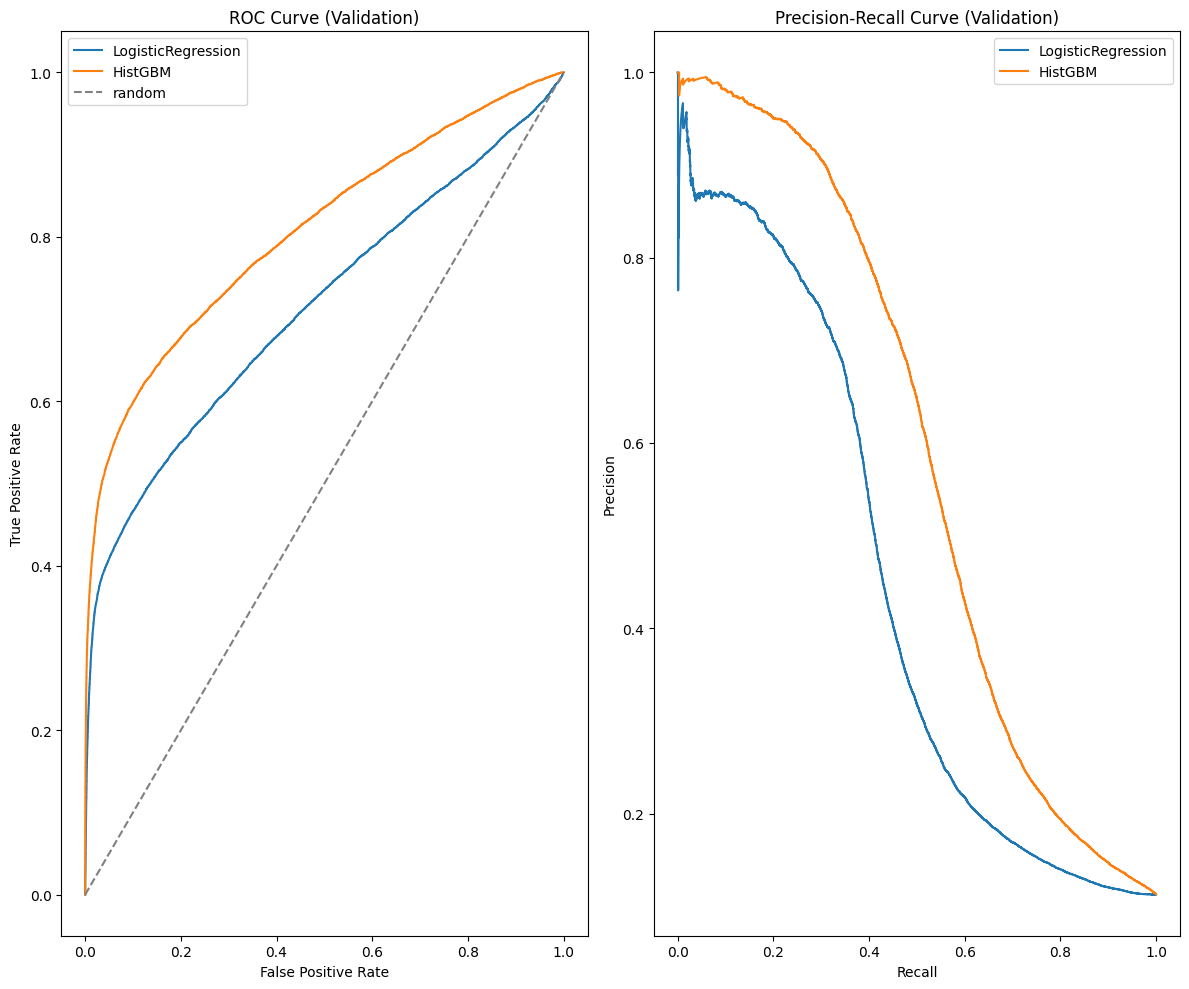

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay

def full_report(y_true, p, threshold, name):
    preds = (p >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, preds, average='binary', zero_division=0)
    cm = confusion_matrix(y_true, preds)
    print(f"{name} with threshold={threshold:.2f}")
    print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")
    print("Confusion matrix [ [TN FP] [FN TP] ]:\n", cm)
    print()

p_val_logit = logit.predict_proba(X_val)[:, 1]
p_val_gbm = gbm.predict_proba(X_val)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# 1. ROC curve - both models
fpr_l, tpr_l, _ = roc_curve(y_val, p_val_logit)
fpr_g, tpr_g, _ = roc_curve(y_val, p_val_gbm)
axes[0].plot(fpr_l, tpr_l, label='LogisticRegression')
axes[0].plot(fpr_g, tpr_g, label='HistGBM')
axes[0].plot([0,1],[0,1],'--', color='gray', label='random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Validation)')
axes[0].legend()

# 2. Precision-Recall curve - both models
prec_l, rec_l, _ = precision_recall_curve(y_val, p_val_logit)
prec_g, rec_g, _ = precision_recall_curve(y_val, p_val_gbm)
axes[1].plot(rec_l, prec_l, label='LogisticRegression')
axes[1].plot(rec_g, prec_g, label='HistGBM')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Validation)')
axes[1].legend()

plt.tight_layout()
plt.savefig('artifacts/m1_model_evaluation.png', dpi=150)
plt.show()

**[M5]**

In [127]:
thresholds_check = [0.05, 0.076, 0.10, 0.20, 0.30, 0.50]
rows = []
for t in thresholds_check:
    preds = (p_val_gbm >= t).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, preds, average='binary', zero_division=0)
    flagged_rate = preds.mean()
    rows.append({'threshold': t, 'precision': precision, 'recall': recall, 'f1': f1, 'pct_flagged': flagged_rate})

trade_off_table = pd.DataFrame(rows)
print(trade_off_table)
trade_off_table.to_csv('artifacts/m1_threshold_table.csv', index=False)

   threshold  precision    recall        f1  pct_flagged
0      0.050   0.161845  0.865174  0.272680     0.601807
1      0.076   0.273691  0.698707  0.393316     0.287400
2      0.100   0.362259  0.636254  0.461664     0.197726
3      0.200   0.595799  0.522321  0.556646     0.098694
4      0.300   0.681206  0.482414  0.564829     0.079725
5      0.500   0.830347  0.372614  0.514395     0.050519


pct_flagged = the percentage of all applicants in my validation set that got labeled "high risk" by the model at that particular threshold

**[M4]**

In [128]:
# Calibration check: bucket predicted probabilities into deciles, compare avg predicted vs actual denial rate
def calibration_table(y_true, p, n_bins=10):
    df_cal = pd.DataFrame({'y': y_true.values, 'p': p})
    df_cal['bucket'] = pd.qcut(df_cal['p'], n_bins, duplicates='drop')
    return df_cal.groupby('bucket', observed=True).agg(n=('y','size'), avg_predicted=('p','mean'), actual_rate=('y','mean'))

print("Calibration (HistGBM):")
print(calibration_table(y_val, p_val_gbm))


Calibration (HistGBM):
                      n  avg_predicted  actual_rate
bucket                                             
(0.0092, 0.0346]  11820       0.029415     0.027496
(0.0346, 0.0403]  11819       0.037617     0.038244
(0.0403, 0.0452]  11819       0.042763     0.043320
(0.0452, 0.0501]  11820       0.047599     0.043486
(0.0501, 0.0554]  11819       0.052687     0.052627
(0.0554, 0.0625]  11819       0.058693     0.055927
(0.0625, 0.0737]  11820       0.067465     0.069120
(0.0737, 0.0993]  11819       0.085578     0.076910
(0.0993, 0.195]   11819       0.128394     0.128268
(0.195, 0.999]    11820       0.577385     0.590355


https://newslink.mba.org/mba-newslinks/2022/july/mba-newslink-monday-july-11-2022/mba-chart-of-the-week-july-8-2002-retail-loan-officer-productivity/


No bank publicly discloses internal review-capacity data for flagged/high-risk applications. Available industry benchmarks (MBA/STRATMOR: around 28 closed loans/underwriter/month, 2021; comparable Canadian postings: 15+ files/month) confirm underwriting capacity is a genuine, scarce constraint industry-wide, though they measure full loan processing, not supplemental risk review specifically. We therefore adopt an operational assumption, flagged applications should not exceed 20% of total volume, rather than claim this figure is drawn directly from industry data.

In [129]:
target_flag_rate = 0.20

sorted_probs = np.sort(p_val_gbm)[::-1] 
cutoff_index = int(len(sorted_probs) * target_flag_rate)
chosen_threshold = sorted_probs[cutoff_index]

print(f"Threshold for around {target_flag_rate:.0%} flagged: {chosen_threshold:.3f}")

full_report(y_val, p_val_gbm, chosen_threshold, f"HistGBM (capacity-targeted, thr={chosen_threshold:.3f})")

Threshold for around 20% flagged: 0.099
HistGBM (capacity-targeted, thr=0.099) with threshold=0.10
Precision=0.359  Recall=0.638  F1=0.460
Confusion matrix [ [TN FP] [FN TP] ]:
 [[89743 15145]
 [ 4812  8494]]



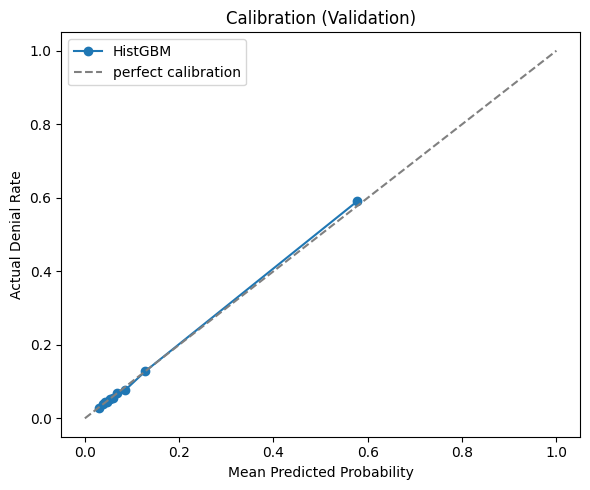

In [130]:
cal = calibration_table(y_val, p_val_gbm)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(cal['avg_predicted'], cal['actual_rate'], marker='o', label='HistGBM')
ax.plot([0,1],[0,1],'--', color='gray', label='perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Actual Denial Rate')
ax.set_title('Calibration (Validation)')
ax.legend()
plt.tight_layout()
plt.show()

This graph tells us that if model says that someone is risky then is it actually right or not?

This caliberation proves that the numbers are honest.

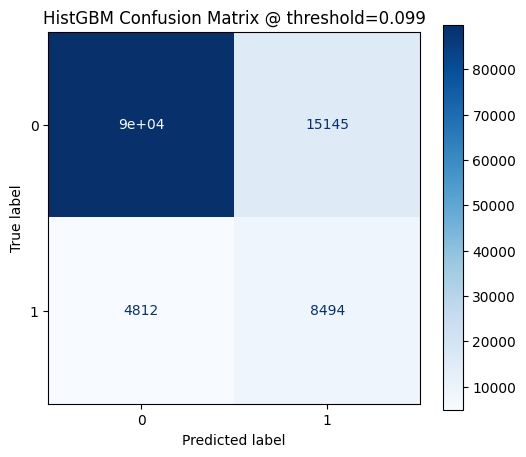

In [142]:
preds_chosen = (p_val_gbm >= chosen_threshold).astype(int)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_val, preds_chosen, cmap='Blues', ax=ax)
ax.set_title(f'HistGBM Confusion Matrix @ threshold={chosen_threshold:.3f}')
plt.savefig('artifacts/m1_model_cm.png', dpi=150)
plt.show()

### M1 Reflection (Write Here)

Use this structure:
1. Which model did you select for the main audit and why?
2. What threshold did you select, and what trade-off did it accept?
3. Which error type is more harmful in this decision context?
4. What model limitation matters most before deployment?


- We selected HistGBM as our main audit model, over LogisticRegression, because it achieved a meaningfully higher ROC-AUC (0.81 vs 0.71) and its predicted probabilities were well-calibrated (validation calibration curve tracked the diagonal closely). 

- We chose threshold = 0.1, corresponding to flagging the top 20% of applicants by predicted risk. This gives recall = 0.638 and precision = 0.359 which means that we catch about 64% of true denials while flagging 20% of all applicants, of whom about 36% are true denials (64% are false alarms). This threshold was chosen based on an assumed operational review capacity of 20% of application volume, since no bank publicly discloses exact review-capacity figures, but industry benchmarks (MBA/STRATMOR: 28 loans/underwriter/month) confirm underwriter capacity is a genuinely scarce, real constraint.

- At our threshold, we have 15,145 false positives (safe applicants flagged unnecessarily) vs 4,812 false negatives (real risks that slip through unflagged). Because this is a decision-support tool, not an auto-deny system, a false positive costs [extra human review time], while a false negative means [a risk that never gets a second look at all]. We judge false negatives as more harmful here because a false positive gets only review time but false negative means loss of money loan provided, which is why we prioritized recall over precision when picking the threshold.

- Our overall ROC-AUC (0.81) and calibration look strong in aggregate, but we have not yet verified whether these hold consistently across race, sex, and age groups.

## M2: Fairness Audit Across Definitions

You must evaluate more than one fairness definition and explain trade-offs among them.

Minimum group/intersectional requirements:
1. Analyze sex, race/ethnicity, age, and at least two intersectional groups.
2. Include sample sizes for every group table.
3. Report at least three group fairness families, such as demographic parity, equal opportunity, equalized odds, predictive parity, calibration within groups, and worst-group performance.
4. Identify where fairness definitions disagree.
5. State which fairness definition is most relevant to your deployment decision and why.

Minimum individual/proxy requirements:
1. Define a similarity function using non-sensitive, decision-relevant features.
2. Compute an individual fairness diagnostic, such as nearest-neighbor score inconsistency.
3. Perform proxy analysis by trying to reconstruct at least one protected attribute from non-protected features.
4. Explain why removing protected attributes alone is insufficient.

Required evidence:
- Group fairness tables `[F1]`
- Intersectional fairness tables `[F2]`
- Fairness-definition trade-off table `[F3]`
- Individual fairness diagnostic `[I1]`
- Proxy reconstruction analysis `[I2]`


In [143]:
val_protected = df.loc[X_val.index, ['race_group', 'ethnicity_group', 'sex_group', 'age_group']].copy()
val_protected['y_true'] = y_val.values
val_protected['p_score'] = gbm.predict_proba(X_val)[:, 1]
val_protected['y_pred'] = (val_protected['p_score'] >= chosen_threshold).astype(int)  # use your saved threshold

print(val_protected.shape)
val_protected.head()

(118194, 7)


,race_group,ethnicity_group,sex_group,age_group,y_true,p_score,y_pred
561891,White,Joint,Joint,25-34,1,0.047418,0
291484,White,Not Hispanic or Latino,Male,45-54,0,0.106831,1
435741,White,Hispanic or Latino,Female,25-34,0,0.137736,1
185885,White,Hispanic or Latino,Joint,<25,0,0.064178,0
427503,White,Hispanic or Latino,Joint,45-54,0,0.501125,1


In [ ]:
# TODO REQUIRED: Compute group fairness metrics.
# Include n, base rate, selection/approval rate, TPR, FPR, FNR, precision/PPV, and uncertainty notes.

def group_fairness_table(data, group_col, min_n=100):
    rows = []
    for g, sub in data.groupby(group_col, observed=True):
        n = len(sub)
        yt, yp = sub['y_true'], sub['y_pred']
        tp = ((yt==1)&(yp==1)).sum(); fp = ((yt==0)&(yp==1)).sum()
        fn = ((yt==1)&(yp==0)).sum(); tn = ((yt==0)&(yp==0)).sum()
        rows.append({
            'group': g, 'n': n,
            'base_rate': yt.mean(),            
            'selection_rate': yp.mean(),   
            'TPR_recall': tp/(tp+fn) if (tp+fn)>0 else np.nan,  
            'FPR': fp/(fp+tn) if (fp+tn)>0 else np.nan,         
            'precision_PPV': tp/(tp+fp) if (tp+fp)>0 else np.nan, 
            'avg_predicted_p': sub['p_score'].mean(),           
            'stable_n100': n >= min_n,  
        })
    return pd.DataFrame(rows).sort_values('n', ascending=False)

race_table = group_fairness_table(val_protected, 'race_group')
print(race_table.to_string(index=False))
race_table.to_csv('artifacts/f1_race_fairness.csv', index=False)


                                    group     n  base_rate  selection_rate  TPR_recall      FPR  precision_PPV  avg_predicted_p  stable_n100
                                    White 58388   0.106717        0.207320    0.649815 0.154457       0.334490         0.112567         True
                       Race Not Available 26266   0.135879        0.229079    0.664612 0.160594       0.394216         0.127277         True
                                    Asian 22846   0.092708        0.138099    0.543437 0.096681       0.364818         0.092718         True
                                    Joint  4739   0.076176        0.135261    0.606648 0.096391       0.341654         0.088857         True
                Black or African American  4440   0.171847        0.296171    0.672346 0.218113       0.390114         0.144515         True
         American Indian or Alaska Native   793   0.179067        0.306431    0.746479 0.210445       0.436214         0.164355         True
Native Hawaii

In [145]:
sex_table = group_fairness_table(val_protected, 'sex_group')
age_table = group_fairness_table(val_protected, 'age_group')
print(sex_table.to_string(index=False))
print(age_table.to_string(index=False))
sex_table.to_csv('artifacts/f1_sex_fairness.csv', index=False)
age_table.to_csv('artifacts/f1_age_fairness.csv', index=False)

            group     n  base_rate  selection_rate  TPR_recall      FPR  precision_PPV  avg_predicted_p  stable_n100
            Joint 50670   0.090290        0.168798    0.615082 0.124504       0.329007         0.097742         True
             Male 36157   0.126421        0.213762    0.626778 0.153992       0.370682         0.118344         True
           Female 23663   0.135444        0.247813    0.699220 0.177095       0.382162         0.136406         True
Sex Not Available  7704   0.123962        0.193795    0.601047 0.136168       0.384461         0.112731         True
group     n  base_rate  selection_rate  TPR_recall      FPR  precision_PPV  avg_predicted_p  stable_n100
35-44 37405   0.105200        0.179308    0.600000 0.129848       0.352020         0.104476         True
25-34 36537   0.098421        0.180037    0.607341 0.133390       0.332016         0.103892         True
45-54 20444   0.124144        0.206809    0.639874 0.145426       0.384106         0.116808         

In [146]:
# TODO REQUIRED: Compute at least two intersectional fairness analyses.
race_sex_table = group_fairness_table(val_protected, ['race_group', 'sex_group'])
print(race_sex_table.to_string(index=False))
race_sex_table.to_csv('artifacts/f2_intersectional_race_sex.csv', index=False)

age_race_table = group_fairness_table(val_protected, ['age_group', 'race_group'])
print(age_race_table.to_string(index=False))
age_race_table.to_csv('artifacts/f2_intersectional_age_race.csv', index=False)

                                                         group     n  base_rate  selection_rate  TPR_recall      FPR  precision_PPV  avg_predicted_p  stable_n100
                                                (White, Joint) 26201   0.085951        0.174077    0.623890 0.131780       0.308046         0.097964         True
                                                 (White, Male) 19345   0.122047        0.221556    0.634477 0.164154       0.349510         0.117466         True
                                               (White, Female) 12583   0.125487        0.254073    0.709943 0.188659       0.350641         0.134975         True
                                                (Asian, Joint)  9796   0.082483        0.126889    0.551980 0.088674       0.358809         0.085881         True
                                   (Race Not Available, Joint)  8542   0.110396        0.201943    0.648993 0.146467       0.354783         0.111053         True
                            

In [147]:
# TODO REQUIRED: Compare fairness definitions across thresholds or model variants.
# Show at least one trade-off where improving one fairness metric worsens another metric or utility metric.

ref = race_table[race_table['group']=='White'].iloc[0]  # reference group
disparity_table = race_table[race_table['stable_n100']].copy()
disparity_table['selection_rate_ratio_vs_White'] = disparity_table['selection_rate'] / ref['selection_rate']
disparity_table['TPR_ratio_vs_White'] = disparity_table['TPR_recall'] / ref['TPR_recall']
disparity_table['FPR_ratio_vs_White'] = disparity_table['FPR'] / ref['FPR']
disparity_table['PPV_ratio_vs_White'] = disparity_table['precision_PPV'] / ref['precision_PPV']

print(disparity_table[['group','n','selection_rate_ratio_vs_White','TPR_ratio_vs_White','FPR_ratio_vs_White','PPV_ratio_vs_White']].to_string(index=False))
disparity_table.to_csv('artifacts/f3_fairness_definition_disagreement.csv', index=False)


                                    group     n  selection_rate_ratio_vs_White  TPR_ratio_vs_White  FPR_ratio_vs_White  PPV_ratio_vs_White
                                    White 58388                       1.000000            1.000000            1.000000            1.000000
                       Race Not Available 26266                       1.104956            1.022770            1.039734            1.178560
                                    Asian 22846                       0.666113            0.836295            0.625941            1.090669
                                    Joint  4739                       0.652424            0.933570            0.624065            1.021417
                Black or African American  4440                       1.428570            1.034672            1.412127            1.166296
         American Indian or Alaska Native   793                       1.478059            1.148755            1.362488            1.304117
Native Hawaiian or Other Pa

In [148]:
# TODO REQUIRED: Implement individual fairness diagnostic and proxy reconstruction analysis.
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Individual fairness: similar people (by NON-protected features only) should get similar scores
sample_idx = X_val.sample(n=5000, random_state=4146).index  # full 118K too slow for pairwise distances
X_sample = X_val.loc[sample_idx, NUMERIC_FEATURES].copy()

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(imputer.fit_transform(X_sample))

nn = NearestNeighbors(n_neighbors=6)  # 5 real neighbors + itself
nn.fit(X_sample_scaled)
distances, indices = nn.kneighbors(X_sample_scaled)

p_sample = pd.Series(p_val, index=X_val.index).loc[sample_idx].values
score_gaps = []
for i in range(len(sample_idx)):
    neighbor_idxs = indices[i][1:]  # exclude the point itself
    max_gap = np.max(np.abs(p_sample[neighbor_idxs] - p_sample[i]))
    score_gaps.append(max_gap)

score_gaps = np.array(score_gaps)
print(f"Mean max score gap among 5 nearest neighbors: {score_gaps.mean():.4f}")
print(f"Median: {np.median(score_gaps):.4f}")
print(f"95th percentile: {np.percentile(score_gaps, 95):.4f}")
print(f"Fraction with gap > 0.10: {(score_gaps > 0.10).mean():.4f}")
print(f"Fraction with gap > 0.20: {(score_gaps > 0.20).mean():.4f}")

pd.DataFrame({'max_neighbor_gap': score_gaps}).to_csv('artifacts/i1_individual_fairness_gaps.csv', index=False)


Mean max score gap among 5 nearest neighbors: 0.1154
Median: 0.0315
95th percentile: 0.5847
Fraction with gap > 0.10: 0.2426
Fraction with gap > 0.20: 0.1766


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

race_train = df.loc[X_train.index, 'race_group']
race_val = df.loc[X_val.index, 'race_group']
is_white_train = (race_train == 'White').astype(int)
is_white_val = (race_val == 'White').astype(int)

proxy_model = HistGradientBoostingClassifier(random_state=4146, max_iter=150, max_depth=6)
proxy_model.fit(X_train, is_white_train)
proxy_pred_proba = proxy_model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(is_white_val, proxy_pred_proba)
print(f"Proxy model AUC (predicting White vs Non-White from non-protected features): {auc:.4f}")
print(f"Baseline (random guessing) would give AUC ~0.50")

samp = X_val.sample(n=8000, random_state=4146)
samp_y = is_white_val.loc[samp.index]
perm = permutation_importance(proxy_model, samp, samp_y, n_repeats=5, random_state=4146, scoring='roc_auc')
proxy_importances = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
print(proxy_importances)
proxy_importances.to_csv('artifacts/i2_proxy_feature_importance.csv')

Proxy model AUC (predicting White vs Non-White from non-protected features): 0.6945
Baseline (random guessing) would give AUC ~0.50
tract_minority_share                 0.102163
ffiec_msa_md_median_family_income    0.060466
tract_income_ratio                   0.020046
property_value                       0.014558
loan_amount                          0.008410
income                               0.006095
loan_type                            0.003379
dti_numeric                          0.002170
tract_population                     0.001781
dti_missing                          0.000000
activity_year                       -0.000116
dtype: float64


### Fairness-Definition Decision Log (Mandatory)

| Fairness definition | What it protects against | Evidence tag | What it misses | Decision relevance |
|---|---|---|---|---|
| Demographic parity | Groups being flagged wildly at different rates regardless of actual risk | [F1]/[F3]: Black selection rate 1.43x White, American Indian 1.48x White | Doesn't account for real differences in base rates (Black base rate 17.2% vs White 10.7%), can flag a model "unfair" even when it's accurately reflecting different underlying risk levels | Useful as an early warning signal, but misleading as the sole standard given real base-rate differences |
| Equal opportunity / equalized odds | Whether the model catches real risk equally well across groups (TPR), and whether it wrongly flags safe applicants equally often (FPR) | [F1]/[F2]: TPR fairly close across groups (0.65-0.75), but FPR notably higher for Black (21.8% vs 15.4% White) and American Indian (21.0%) | Doesn't check if flagged people are actually likely to be correct (that's predictive parity) | Most decision-relevant here — FPR gap means safe Black/American Indian applicants face disproportionate extra scrutiny, a real, direct fairness harm |
| Predictive parity / calibration | Whether a "flagged" applicant means the same thing (same real risk) across groups | `[F1]`/`[F3]`: PPV actually higher for Black (0.39) and American Indian (0.44) than White (0.33); overall calibration `[M4]` was strong | Doesn't catch unequal false-positive burden — a group can have great predictive parity while still bearing more false alarms | Reassuring on its own, but doesn't resolve the FPR concern — shows definitions genuinely disagree here |
| Individual similarity / proxy risk | Whether similar applicants get similar treatment, and whether "removing" protected attributes actually removes their influence | `[I1]`: 24.3% of applicants have a similar peer with a >0.10 score gap; `[I2]`: race predictable at AUC=0.69 from non-protected features, driven overwhelmingly by `tract_minority_share` | Doesn't summarize group-level patterns; a separate lens entirely | Critical — proves race-blind ≠ discrimination-blind; `tract_minority_share` is functioning as a redlining-era proxy |


Conclude with: Which definition receives the most weight in your deployment recommendation, and why?


We weight **equalized odds (specifically the FPR gap)** most heavily, because it identifies a concrete, direct harm that the safe Black and American Indian/Alaska Native applicants face meaningfully higher rates of unnecessary flagging (21-22% vs 15% for White applicants), and this harm exists despite strong predictive parity, meaning it can't be dismissed by pointing to "the flags are still accurate." We treat the proxy-reconstruction finding ([I2]) as equally critical evidence, since it explains why this gap likely persists even without race as a direct input: tract_minority_share, the single strongest proxy for race in the model, is also present in the feature set, and its removal or transformation is now a clear candidate for M3 mitigation.

## M3: Mitigation and Trade-Off Analysis

Implement at least two mitigation approaches from different categories.

Allowed categories:
1. Data or feature intervention: reweighting, resampling, proxy feature removal, feature transformation.
2. Training intervention: fairness-aware objective, constrained model, group-robust or cost-sensitive learning.
3. Decision intervention: threshold adjustment, reject-option review, calibrated post-processing, human-review routing.

Minimum requirements:
1. Compare baseline vs each mitigation using utility and fairness metrics.
2. Explain which groups benefit and which do not.
3. Report costs, calibration changes, and any harmed-group trade-offs.
4. Do not declare success from one improved fairness metric alone.

Required evidence:
- Mitigation design table `[G1]`
- Baseline vs mitigation comparison `[G2]`
- Harmed/benefited group analysis `[G3]`
- Mitigation recommendation with limitations `[G4]`


In [136]:
# TODO REQUIRED: Implement mitigation approach 1.

# Your code here


In [137]:
# TODO REQUIRED: Implement mitigation approach 2 from a different category.

# Your code here


In [138]:
# TODO REQUIRED: Compare baseline and mitigated systems on utility, calibration, and multiple fairness definitions.

# Your code here


### Mitigation Trade-Off Log (Mandatory)

For each mitigation, answer:
1. What changed technically?
2. Which fairness metric improved?
3. Which utility or fairness metric worsened?
4. Which groups benefited?
5. Which groups remained at risk?
6. Would you recommend this mitigation for deployment? Why or why not?


## M4: Production Monitoring and Incident Response

Minimum requirements:
1. Create production-era batches using time, geography, lender, or another justified ordering.
2. Track data quality, feature/score drift, group composition, performance by group, and fairness by group/intersection.
3. Define alert thresholds and minimum sample-size rules.
4. Trigger at least one simulated alert.
5. Complete an investigation worksheet for that alert.

Required evidence:
- Batch construction and reference period `[P1]`
- Monitoring metric table `[P2]`
- Alert policy `[P3]`
- Incident investigation worksheet `[P4]`


In [139]:
# TODO REQUIRED: Build production-style batches and monitoring tables.

# Your code here


In [140]:
# TODO REQUIRED: Define alert rules and trigger at least one simulated incident.

# Your code here


### Incident Investigation Worksheet (Mandatory)

For one alert, complete:

- Alert ID:
- Affected population:
- Metric that changed:
- Reference value:
- Alert-period value:
- When the change began:
- Minimum sample-size check:
- Candidate causes:
- Supporting analyses:
- Immediate containment action:
- Long-term remediation:
- Conditions for returning to normal operation:
- Why this alert does or does not change your deployment recommendation:


## M5: Final Recommendation and Model Card

Your final decision must be one of:
1. Deploy as-is.
2. Deploy with controls.
3. Return for remediation.
4. Reject for this use case.

Minimum requirements:
1. Link your recommendation to model, fairness, mitigation, and monitoring evidence.
2. State controls required for safe operation.
3. Discuss limitations and historical-label risks.
4. Include a concise model card.

Required evidence:
- Deployment decision `[R1]`
- Conditions and controls `[R2]`
- Model card `[R3]`


### Final Deployment Recommendation (Write Here)

Use this structure:
1. Decision: deploy as-is / deploy with controls / remediate / reject.
2. Main evidence supporting the decision.
3. Main fairness concern.
4. Required operational controls.
5. Conditions that would cause the system to be paused or rolled back.
6. What evidence would change your recommendation?


### Model Card (Required)

Fill this template.

- Model name/version:
- Intended use:
- Out-of-scope uses:
- Training data summary:
- Target-label definition and limitations:
- Key features used:
- Protected attributes audited:
- Performance summary:
- Fairness summary:
- Mitigation summary:
- Monitoring commitments:
- Known limitations:
- Human oversight requirements:
- Approval conditions:


## Artifact Export

Export all key outputs (and/or artifacts that support your claim) needed for TA grading reproducibility.

Example expected files:
- `artifacts/d0_data_summary.csv`
- `artifacts/m1_model_comparison.csv`
- `artifacts/m1_threshold_table.csv`
- `artifacts/f2_group_fairness.csv`
- `artifacts/f2_intersectional_fairness.csv`
- `artifacts/i1_individual_proxy_summary.csv`
- `artifacts/g1_mitigation_comparison.csv`
- `artifacts/p0_monitoring_table.csv`
- `artifacts/p1_alerts.csv`
- `artifacts/r0_final_decision.json`


In [141]:
# TODO REQUIRED: Export your grading artifacts with stable filenames.

# Your code here


## Oral Defense Readiness (Mandatory)

Prepare concise answers using your own evidence.

1. Why is your target label useful but not neutral ground truth?
2. Which leakage risks did you remove from the model?
3. Which fairness definition mattered most for your deployment decision?
4. Give one example where fairness definitions conflicted.
5. Which mitigation did you prefer, and what trade-off did it create?
6. What monitoring alert would cause you to pause deployment?


## Evidence Reference Map (Required)

Before submission, map every major claim to a concrete output.

Use this format:
- `[D1]`: table/plot name + claim
- `[M1]`: table/plot name + claim
- `[F1]`: table/plot name + claim
- `[I1]`: table/plot name + claim
- `[G1]`: table/plot name + claim
- `[P1]`: table/plot name + claim
- `[R1]`: final recommendation evidence

Claims that cannot be mapped to evidence are not decision-ready.


## Submission Checklist

- [ ] Team configuration is complete.
- [ ] M0-M5 sections are complete.
- [ ] Historical-label limitations are discussed.
- [ ] Train/validation/test split is leakage-safe.
- [ ] Threshold chosen on validation data only.
- [ ] Group and intersectional fairness tables include sample sizes.
- [ ] At least three fairness definition families are compared.
- [ ] Individual fairness and proxy analyses are included.
- [ ] Two mitigation approaches from different categories are compared.
- [ ] Monitoring batches and alert policy are implemented.
- [ ] One incident investigation worksheet is complete.
- [ ] Model card and final deployment recommendation are complete.
- [ ] Required artifacts are exported under `artifacts/`.
- [ ] Evidence reference map is complete.
- [ ] AI/source disclosure is included if applicable.
